In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

In [13]:
X_train = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task3\training_data_set_23_labeled_data.csv').values
y_train = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task3\training_data_set_23_labeled_labels.csv').values
X_val = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task3\validation_data_set_23_data.csv').values
y_val = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task3\validation_data_set_23_labels.csv').values
X_test = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task3\testing_data_set_23_data.csv').values
y_test = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task3\testing_data_set_23_labels.csv').values

In [14]:
# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# PCA (retain 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_train = pca.fit_transform(X_train)
X_val   = pca.transform(X_val)
X_test  = pca.transform(X_test)

print("Original features:", scaler.mean_.shape[0])
print("After PCA:", X_train.shape[1])

Original features: 36
After PCA: 30


In [15]:
def one_hot(y, num_classes):
    y = y.astype(int).flatten()
    oh = np.zeros((y.size, num_classes))
    oh[np.arange(y.size), y] = 1
    return oh

num_classes = len(np.unique(y_train))

y_train = one_hot(y_train, num_classes)
y_val   = one_hot(y_val, num_classes)
y_test  = one_hot(y_test, num_classes)

In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [17]:
def initialize_weights(layer_sizes):
    params = {}
    for i in range(1, len(layer_sizes)):
        params[f"W{i}"] = np.random.randn(
            layer_sizes[i-1], layer_sizes[i]
        ) * np.sqrt(2 / layer_sizes[i-1])
        params[f"b{i}"] = np.zeros((1, layer_sizes[i]))
    return params


def initialize_adam(params):
    v, s = {}, {}
    for k in params:
        v[k] = np.zeros_like(params[k])
        s[k] = np.zeros_like(params[k])
    return v, s

In [18]:
def forward_propagation(X, params):
    cache = {}
    A = X

    L = len(params) // 2
    for i in range(1, L):
        Z = A @ params[f"W{i}"] + params[f"b{i}"]
        A = sigmoid(Z)
        cache[f"A{i}"] = A

    ZL = A @ params[f"W{L}"] + params[f"b{L}"]
    AL = softmax(ZL)

    cache["A0"] = X
    cache["AL"] = AL
    return AL, cache


def backward_propagation(Y, cache, params):
    grads = {}
    m = Y.shape[0]
    L = len(params) // 2

    dZ = cache["AL"] - Y
    grads[f"W{L}"] = cache[f"A{L-1}"].T @ dZ / m
    grads[f"b{L}"] = np.sum(dZ, axis=0, keepdims=True) / m

    for i in reversed(range(1, L)):
        dA = dZ @ params[f"W{i+1}"].T
        dZ = dA * sigmoid_derivative(cache[f"A{i}"])
        grads[f"W{i}"] = cache[f"A{i-1}"].T @ dZ / m
        grads[f"b{i}"] = np.sum(dZ, axis=0, keepdims=True) / m

    return grads

In [19]:
#using Adam optimizer
def train_DFNN(X, Y, layer_sizes, lr=0.001, batch_size=64, epochs=50):

    params = initialize_weights(layer_sizes)
    v, s = initialize_adam(params)

    for epoch in range(epochs):

        perm = np.random.permutation(X.shape[0])
        X, Y = X[perm], Y[perm]
        total_loss = 0

        for i in range(0, X.shape[0], batch_size):

            Xb = X[i:i+batch_size]
            Yb = Y[i:i+batch_size]

            AL, cache = forward_propagation(Xb, params)
            grads = backward_propagation(Yb, cache, params)

            for k in params:
                v[k] = 0.9 * v[k] + 0.1 * grads[k]
                s[k] = 0.999 * s[k] + 0.001 * (grads[k] ** 2)
                params[k] -= lr * v[k] / (np.sqrt(s[k]) + 1e-8)

            total_loss += -np.mean(
                np.sum(Yb * np.log(AL + 1e-8), axis=1)
            )

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

    return params

In [20]:
layer_sizes = [X_train.shape[1], 256, 128, 64, y_train.shape[1]]

params_sup = train_DFNN(X_train, y_train, layer_sizes)

train_pred_sup, _ = forward_propagation(X_train, params_sup)
test_pred_sup, _  = forward_propagation(X_test, params_sup)

cm_sup_train = confusion_matrix(
    np.argmax(y_train,1),
    np.argmax(train_pred_sup,1)
)

cm_sup_test = confusion_matrix(
    np.argmax(y_test,1),
    np.argmax(test_pred_sup,1)
)

Epoch 1/50 | Loss: 21.7712
Epoch 2/50 | Loss: 18.7608
Epoch 3/50 | Loss: 17.3557
Epoch 4/50 | Loss: 15.6684
Epoch 5/50 | Loss: 14.3339
Epoch 6/50 | Loss: 13.7443
Epoch 7/50 | Loss: 13.2704
Epoch 8/50 | Loss: 12.9490
Epoch 9/50 | Loss: 12.7286
Epoch 10/50 | Loss: 12.3748
Epoch 11/50 | Loss: 12.1276
Epoch 12/50 | Loss: 12.0324
Epoch 13/50 | Loss: 11.8965
Epoch 14/50 | Loss: 11.6964
Epoch 15/50 | Loss: 11.4944
Epoch 16/50 | Loss: 11.3792
Epoch 17/50 | Loss: 11.3031
Epoch 18/50 | Loss: 11.2734
Epoch 19/50 | Loss: 11.1126
Epoch 20/50 | Loss: 10.7786
Epoch 21/50 | Loss: 10.7946
Epoch 22/50 | Loss: 10.7117
Epoch 23/50 | Loss: 10.7260
Epoch 24/50 | Loss: 10.3754
Epoch 25/50 | Loss: 10.3504
Epoch 26/50 | Loss: 10.2023
Epoch 27/50 | Loss: 9.9951
Epoch 28/50 | Loss: 10.0144
Epoch 29/50 | Loss: 9.8578
Epoch 30/50 | Loss: 9.7885
Epoch 31/50 | Loss: 9.6400
Epoch 32/50 | Loss: 9.5408
Epoch 33/50 | Loss: 9.3846
Epoch 34/50 | Loss: 9.2037
Epoch 35/50 | Loss: 9.1378
Epoch 36/50 | Loss: 9.0159
Epoch 37/5

In [21]:
def train_autoencoder(X, input_size, hidden_size,
                      lr=0.001, batch_size=64, epochs=30):

    params = initialize_weights([input_size, hidden_size, input_size])
    v, s = initialize_adam(params)

    for _ in range(epochs):

        perm = np.random.permutation(X.shape[0])
        X = X[perm]

        for i in range(0, X.shape[0], batch_size):

            Xb = X[i:i+batch_size]

            Z1 = Xb @ params["W1"] + params["b1"]
            A1 = sigmoid(Z1)
            Z2 = A1 @ params["W2"] + params["b2"]
            A2 = sigmoid(Z2)

            dZ2 = (A2 - Xb) * sigmoid_derivative(A2)
            dW2 = A1.T @ dZ2 / Xb.shape[0]
            db2 = np.sum(dZ2, axis=0, keepdims=True) / Xb.shape[0]

            dA1 = dZ2 @ params["W2"].T
            dZ1 = dA1 * sigmoid_derivative(A1)
            dW1 = Xb.T @ dZ1 / Xb.shape[0]
            db1 = np.sum(dZ1, axis=0, keepdims=True) / Xb.shape[0]

            grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

            for k in params:
                v[k] = 0.9 * v[k] + 0.1 * grads[k]
                s[k] = 0.999 * s[k] + 0.001 * (grads[k]**2)
                params[k] -= lr * v[k] / (np.sqrt(s[k]) + 1e-8)

    return params

In [22]:
AE1 = train_autoencoder(X_train, X_train.shape[1], 256)
H1  = sigmoid(X_train @ AE1["W1"] + AE1["b1"])

AE2 = train_autoencoder(H1, 256, 128)
H2  = sigmoid(H1 @ AE2["W1"] + AE2["b1"])

AE3 = train_autoencoder(H2, 128, 64)

In [23]:
params_pre = initialize_weights(layer_sizes)

params_pre["W1"], params_pre["b1"] = AE1["W1"], AE1["b1"]
params_pre["W2"], params_pre["b2"] = AE2["W1"], AE2["b1"]
params_pre["W3"], params_pre["b3"] = AE3["W1"], AE3["b1"]

In [24]:
params_pre = train_DFNN(X_train, y_train, layer_sizes)

Epoch 1/50 | Loss: 19.0879
Epoch 2/50 | Loss: 15.9527
Epoch 3/50 | Loss: 14.2146
Epoch 4/50 | Loss: 13.1024
Epoch 5/50 | Loss: 12.7920
Epoch 6/50 | Loss: 12.3047
Epoch 7/50 | Loss: 12.1760
Epoch 8/50 | Loss: 12.1095
Epoch 9/50 | Loss: 11.8168
Epoch 10/50 | Loss: 11.6356
Epoch 11/50 | Loss: 11.4420
Epoch 12/50 | Loss: 11.2841
Epoch 13/50 | Loss: 11.3500
Epoch 14/50 | Loss: 11.2168
Epoch 15/50 | Loss: 11.0998
Epoch 16/50 | Loss: 10.9094
Epoch 17/50 | Loss: 10.7755
Epoch 18/50 | Loss: 10.5540
Epoch 19/50 | Loss: 10.4771
Epoch 20/50 | Loss: 10.3220
Epoch 21/50 | Loss: 10.3187
Epoch 22/50 | Loss: 10.0998
Epoch 23/50 | Loss: 9.9693
Epoch 24/50 | Loss: 9.8649
Epoch 25/50 | Loss: 9.7883
Epoch 26/50 | Loss: 9.7916
Epoch 27/50 | Loss: 9.5374
Epoch 28/50 | Loss: 9.4920
Epoch 29/50 | Loss: 9.3093
Epoch 30/50 | Loss: 9.0852
Epoch 31/50 | Loss: 9.0206
Epoch 32/50 | Loss: 8.8143
Epoch 33/50 | Loss: 8.6617
Epoch 34/50 | Loss: 8.5296
Epoch 35/50 | Loss: 8.4388
Epoch 36/50 | Loss: 8.6151
Epoch 37/50 | L

In [25]:
train_pred_pre, _ = forward_propagation(X_train, params_pre)
test_pred_pre, _  = forward_propagation(X_test, params_pre)

cm_pre_train = confusion_matrix(
    np.argmax(y_train,1),
    np.argmax(train_pred_pre,1)
)

cm_pre_test = confusion_matrix(
    np.argmax(y_test,1),
    np.argmax(test_pred_pre,1)
)

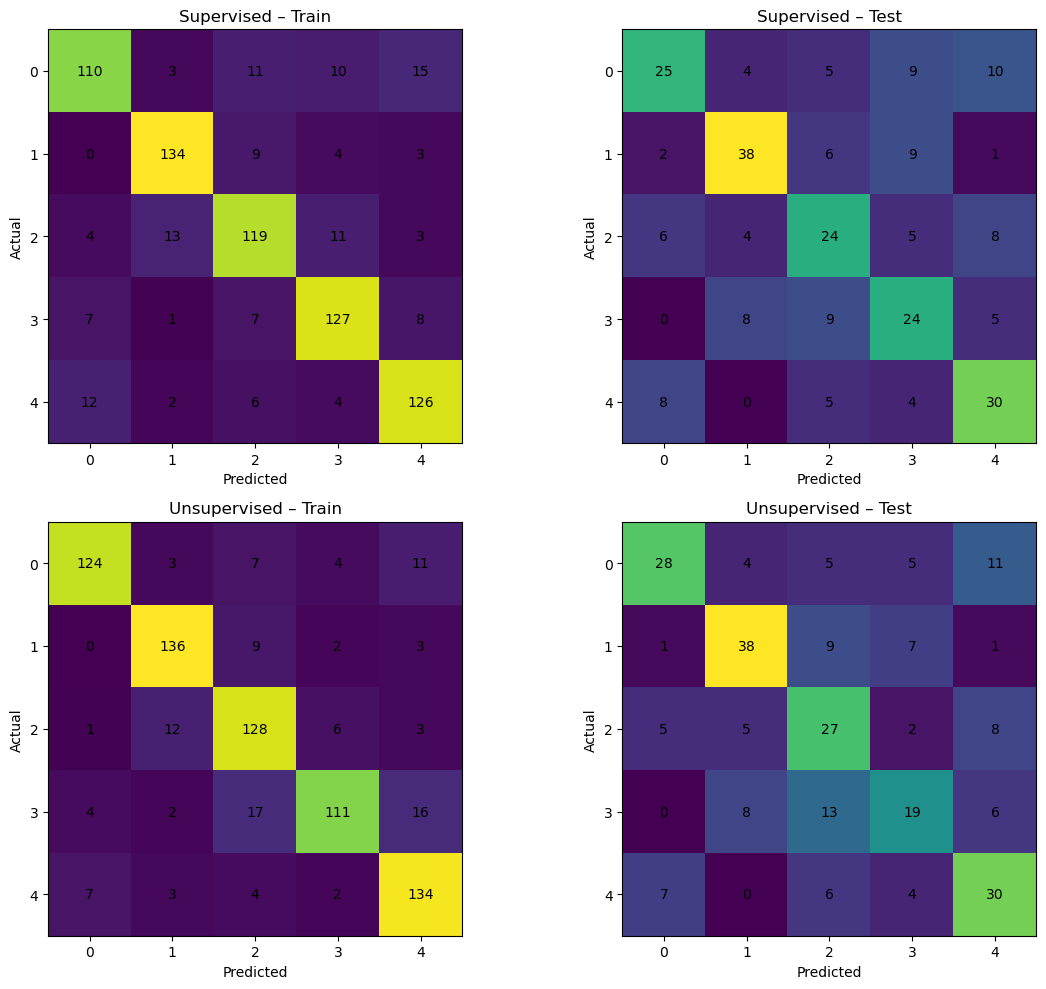

In [26]:
def show_4_confusion_matrices(cm1, cm2, cm3, cm4):

    titles = [
        "Supervised – Train",
        "Supervised – Test",
        "Unsupervised – Train",
        "Unsupervised – Test"
    ]

    cms = [cm1, cm2, cm3, cm4]
    fig, axes = plt.subplots(2, 2, figsize=(12,10))

    for ax, cm, title in zip(axes.flatten(), cms, titles):
        ax.imshow(cm)
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i,j], ha="center", va="center")

    plt.tight_layout()
    plt.show()


show_4_confusion_matrices(
    cm_sup_train,
    cm_sup_test,
    cm_pre_train,
    cm_pre_test
)